Data Preprocessing for EV Charging Patterns

1. Data Imports & Initial Set Up

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

data_path = 'data/raw/4-ev_charging_patterns.csv'
target_col = 'Charging Cost (USD)'

data = pd.read_csv(data_path)

print('Shape:', data.shape)
data.head()

Shape: (1320, 20)


,User ID,Vehicle Model,Battery Capacity (kWh),Charging Station ID,Charging Station Location,Charging Start Time,Charging End Time,Energy Consumed (kWh),Charging Duration (hours),Charging Rate (kW),Charging Cost (USD),Time of Day,Day of Week,State of Charge (Start %),State of Charge (End %),Distance Driven (since last charge) (km),Temperature (°C),Vehicle Age (years),Charger Type,User Type
0,User_1,BMW i3,108.463007,Station_391,Houston,2024-01-01 00:00:00,2024-01-01 00:39:00,60.712346,0.591363,36.389181,13.087717,Evening,Tuesday,29.371576,86.119962,293.602111,27.947953,2.0,DC Fast Charger,Commuter
1,User_2,Hyundai Kona,100.000000,Station_428,San Francisco,2024-01-01 01:00:00,2024-01-01 03:01:00,12.339275,3.133652,30.677735,21.128448,Morning,Monday,10.115778,84.664344,112.112804,14.311026,3.0,Level 1,Casual Driver
2,User_3,Chevy Bolt,75.000000,Station_181,San Francisco,2024-01-01 02:00:00,2024-01-01 04:48:00,19.128876,2.452653,27.513593,35.667270,Morning,Thursday,6.854604,69.917615,71.799253,21.002002,2.0,Level 2,Commuter
3,User_4,Hyundai Kona,50.000000,Station_327,Houston,2024-01-01 03:00:00,2024-01-01 06:42:00,79.457824,1.266431,32.882870,13.036239,Evening,Saturday,83.120003,99.624328,199.577785,38.316313,1.0,Level 1,Long-Distance Traveler
4,User_5,Hyundai Kona,50.000000,Station_108,Los Angeles,2024-01-01 04:00:00,2024-01-01 05:46:00,19.629104,2.019765,10.215712,10.161471,Morning,Saturday,54.258950,63.743786,203.661847,-7.834199,1.0,Level 1,Long-Distance Traveler


2. Initial Exploration

In [4]:
print('--- Data Types ---')
print(data.dtypes)

print('\n--- Basic Statistics ---')
print(data.describe(include=[np.number]))

print('\n--- Missing values ---')
print(data.isna().sum())

--- Data Types ---
User ID                                         str
Vehicle Model                                   str
Battery Capacity (kWh)                      float64
Charging Station ID                             str
Charging Station Location                       str
Charging Start Time                             str
Charging End Time                               str
Energy Consumed (kWh)                       float64
Charging Duration (hours)                   float64
Charging Rate (kW)                          float64
Charging Cost (USD)                         float64
Time of Day                                     str
Day of Week                                     str
State of Charge (Start %)                   float64
State of Charge (End %)                     float64
Distance Driven (since last charge) (km)    float64
Temperature (°C)                            float64
Vehicle Age (years)                         float64
Charger Type                                 

3. Handling Missing Values

In [14]:
# Drops rows where target is missing
data_clean = data.dropna(subset=[target_col]).copy()

# Drops columns with >50% missing
threshold = len(data_clean) * 0.5
data_clean = data_clean.dropna(thresh=threshold, axis=1)

# Fills numeric with median
numeric_cols = data_clean.select_dtypes(include=np.number).columns
data_clean[numeric_cols] = data_clean[numeric_cols].fillna(data_clean[numeric_cols].median())

# Fills categorical with mode
categorical_cols = data_clean.select_dtypes(include='string').columns
for col in categorical_cols:
    data_clean[col].fillna(data_clean[col].mode()[0], inplace=True)

print("Remaining missing values:")
print(data_clean.isna().sum())

Remaining missing values:
User ID                                     0
Vehicle Model                               0
Battery Capacity (kWh)                      0
Charging Station ID                         0
Charging Station Location                   0
Charging Start Time                         0
Charging End Time                           0
Energy Consumed (kWh)                       0
Charging Duration (hours)                   0
Charging Rate (kW)                          0
Charging Cost (USD)                         0
Time of Day                                 0
Day of Week                                 0
State of Charge (Start %)                   0
State of Charge (End %)                     0
Distance Driven (since last charge) (km)    0
Temperature (°C)                            0
Vehicle Age (years)                         0
Charger Type                                0
User Type                                   0
dtype: int64


/tmp/ipykernel_13595/185247934.py:15: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data_clean[col].fillna(data_clean[col].mode()[0], inplace=True)


4. Removing Duplicates

In [15]:
print("Duplicates before:", data_clean.duplicated().sum())
data_clean = data_clean.drop_duplicates()
print("Duplicates after:", data_clean.duplicated().sum())

Duplicates before: 0
Duplicates after: 0


5. Standardizing Formatting of Values: Timestamp Processing & Rounding Numeric Values

In [16]:
data_clean['Charging Start Time'] = pd.to_datetime(data_clean['Charging Start Time']).dt.date
data_clean['Charging End Time'] = pd.to_datetime(data_clean['Charging End Time']).dt.date

numeric_cols = data_clean.select_dtypes(include=np.number).columns
data_clean[numeric_cols] = data_clean[numeric_cols].astype(float).round(2)

6. Categorical Encoding

In [30]:
ONEHOT_THRESHOLD = 10

categorical_cols = data_clean.select_dtypes(include='string').columns

onehot_cols = [c for c in categorical_cols if data_clean[c].nunique() <= ONEHOT_THRESHOLD]
freq_cols = [c for c in categorical_cols if c not in onehot_cols]

print("One-hot:", onehot_cols)
print("Frequency:", freq_cols)

data_encoded = pd.get_dummies(data_clean, columns=onehot_cols, drop_first=False)

data_encoded.drop(columns=freq_cols, inplace=True)

print("Shape after encoding:", data_encoded.shape)

One-hot: ['Vehicle Model', 'Charging Station Location', 'Time of Day', 'Day of Week', 'Charger Type', 'User Type']
Frequency: ['User ID', 'Charging Station ID']
Shape after encoding: (1320, 39)


7. Outlier Handling

In [31]:
numeric_features = data_encoded.select_dtypes(include=np.number).columns

exclude_cols = [target_col] + [c for c in numeric_features if data_encoded[c].nunique() <= 2]
cap_cols = [c for c in numeric_features if c not in exclude_cols]

for col in cap_cols:
    mean = data_encoded[col].mean()
    std = data_encoded[col].std()
    if std == 0:
        continue
    data_encoded[col] = data_encoded[col].clip(mean - 3*std, mean + 3*std)

8. Train-Validation-Test Split

In [32]:
X = data_encoded.drop(columns=[target_col])
y = data_encoded[target_col]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (924, 38)
Validation: (198, 38)
Test: (198, 38)


9. Feature Scaling

In [33]:
from sklearn.preprocessing import StandardScaler

# Only numeric columns (int, float) for scaling
scale_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

scaler = StandardScaler()

X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_val[scale_cols] = scaler.transform(X_val[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])

10. Save Processed Files

In [34]:
data_encoded.to_csv('data/processed/4-ev_charging_processed.csv', index=False)

X_train.to_csv('data/processed/4-ev_charging_X_train.csv', index=False)
X_val.to_csv('data/processed/4-ev_charging_X_val.csv', index=False)
X_test.to_csv('data/processed/4-ev_charging_X_test.csv', index=False)

y_train.to_csv('data/processed/4-ev_charging_y_train.csv', index=False)
y_val.to_csv('data/processed/4-ev_charging_y_val.csv', index=False)
y_test.to_csv('data/processed/4-ev_charging_y_test.csv', index=False)

print("All files saved under proper path.")

All files saved under proper path.


11. Visualizing with the Dataset

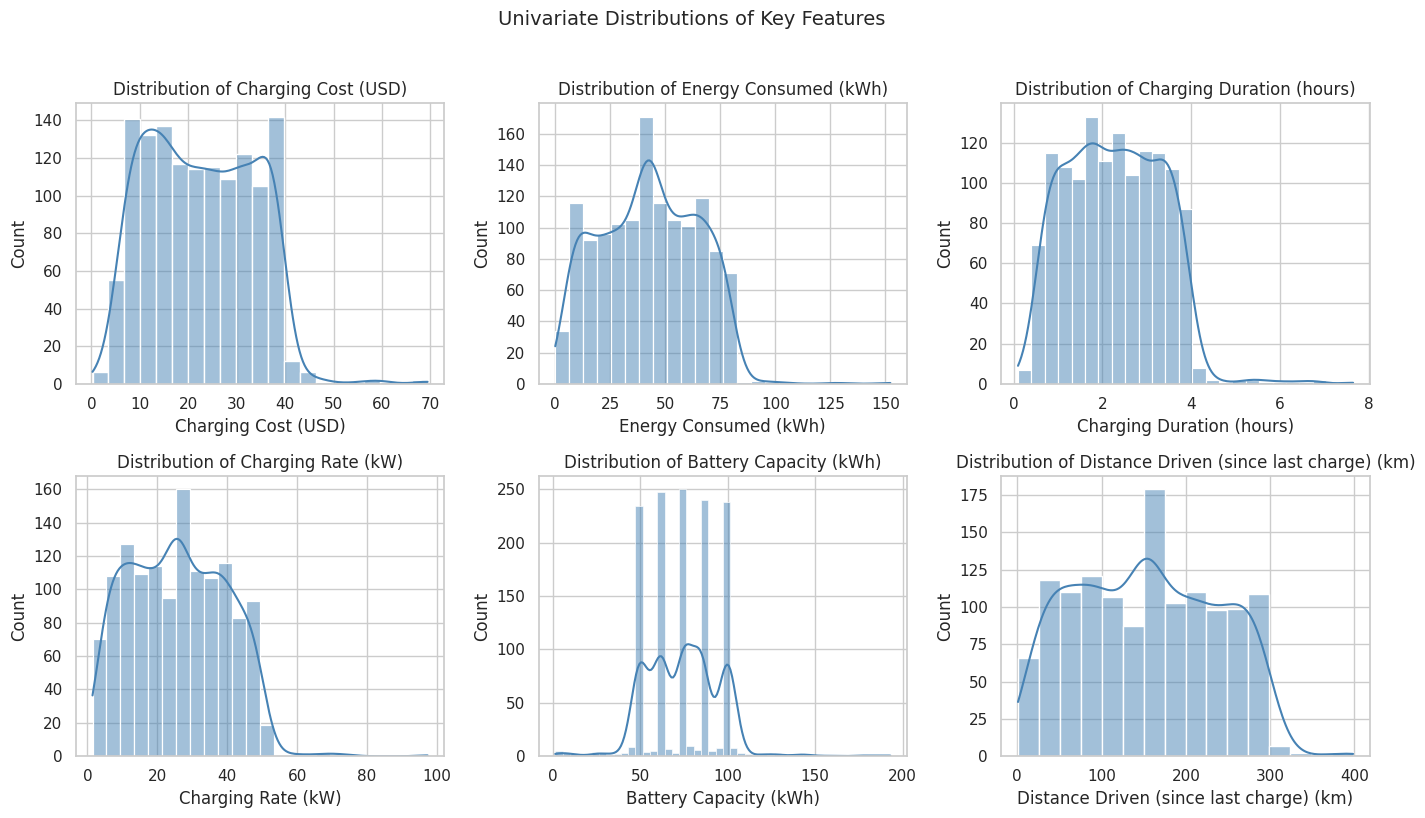

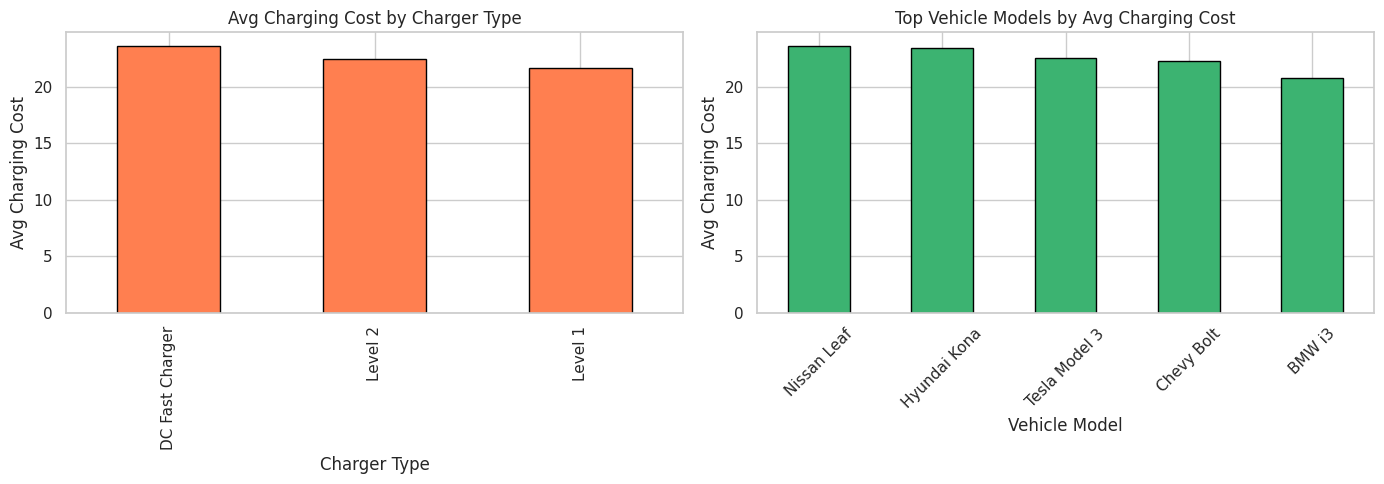

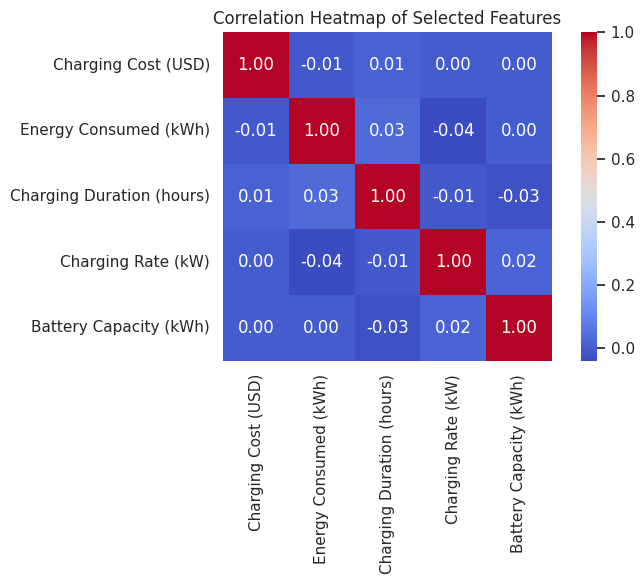

In [36]:
# Sample of Data
plot_df_raw = data_clean.copy()
plot_df_raw = plot_df_raw.sample(n=min(20000, len(plot_df_raw)), random_state=42)


# Univariate Distributions
cont_features = [target_col]

# Add relevant numeric features for this dataset
for c in [
    'Energy Consumed (kWh)',
    'Charging Duration (hours)',
    'Charging Rate (kW)',
    'Battery Capacity (kWh)',
    'Distance Driven (since last charge) (km)'
]:
    if c in plot_df_raw.columns:
        cont_features.append(c)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(cont_features):
    sns.histplot(plot_df_raw[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)

# Hide unused plots
for j in range(len(cont_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Univariate Distributions of Key Features', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


# Multivariate Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Avg Charging Cost by Charger Type
if 'Charger Type' in plot_df_raw.columns:
    charger_avg = plot_df_raw.groupby('Charger Type')[target_col].mean().sort_values(ascending=False)
    charger_avg.plot.bar(ax=axes[0], color='coral', edgecolor='black')
    axes[0].set_title('Avg Charging Cost by Charger Type')
    axes[0].set_xlabel('Charger Type')
    axes[0].set_ylabel('Avg Charging Cost')

# Avg Charging Cost by Vehicle Model
if 'Vehicle Model' in plot_df_raw.columns:
    model_avg = plot_df_raw.groupby('Vehicle Model')[target_col].mean().sort_values(ascending=False).head(10)
    model_avg.plot.bar(ax=axes[1], color='mediumseagreen', edgecolor='black')
    axes[1].set_title('Top Vehicle Models by Avg Charging Cost')
    axes[1].set_xlabel('Vehicle Model')
    axes[1].set_ylabel('Avg Charging Cost')
    axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


# Correlation Heatmap
numeric_cols_plot = [c for c in [
    target_col,
    'Energy Consumed (kWh)',
    'Charging Duration (hours)',
    'Charging Rate (kW)',
    'Battery Capacity (kWh)'
] if c in data_encoded.columns]

# Add some encoded features
freq_candidates = [c for c in data_encoded.columns if c.endswith('_freq')]
numeric_cols_plot += freq_candidates[:10]

numeric_cols_plot = list(dict.fromkeys(numeric_cols_plot))

if len(numeric_cols_plot) >= 2:
    corr = data_encoded[numeric_cols_plot].corr()

    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
    plt.title('Correlation Heatmap of Selected Features')
    plt.tight_layout()
    plt.show()